In [1]:
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D
from os import listdir
from keras.utils import img_to_array
import cv2
from sklearn.model_selection import train_test_split
import numpy as np
import distutils

# set random seed
np.random.seed(42)

# root folder
root_dir=r"D:\nhandangsaubenhtrencaylua\nhan dien sau benh tren cay lua\dataset\train_images"

In [2]:
def convert_img_to_tensor(fpath):
    #read image
    img = cv2.imread(fpath)
    img = cv2.resize(img,(256,256))
    
    #converts image to array
    res = img_to_array(img)
    
    return res

def get_img_data_and_label(root_dir):
    dire=listdir(root_dir)
    
    image_dataset=[]
    image_label=[]
    classes=[]
    
    binary_label=[]
    i=0
    
    for subdir in dire:
        binary_label.append(i)
        classes.append(subdir)
        i+=1
        
    index=0
    
    for subdir in dire:
        skin_img_list=listdir(f"{root_dir}/{subdir}")
        
        for imgfile in skin_img_list:
            
            filepath=f"{root_dir}/{subdir}/{imgfile}"
            #convert image to array
            res=convert_img_to_tensor(filepath)
            #add data to dataset list
            image_dataset.append(res)
            image_label.append(binary_label[index])
            
        index+=1
        
    return image_dataset,image_label,len(binary_label),classes

In [3]:

image_dataset,image_labels,NoOfOutputLayer,classes = get_img_data_and_label(root_dir)

In [4]:
print(NoOfOutputLayer)
print(len(image_labels))
print(len(image_dataset))
print(image_dataset[0].shape)
print(classes)

10
12145
12145
(256, 256, 3)
['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [5]:
xtrain,xtest,ytrain,ytest=train_test_split(image_dataset,image_labels,test_size=0.2,random_state=100)

from keras.utils import to_categorical
ytrain=to_categorical(ytrain)
ytest=to_categorical(ytest)



xtrain = np.array(xtrain, dtype=np.float16)/ 255.0
xtrain = xtrain.reshape(-1,256,256,3)
xtest = np.array(xtest, dtype=np.float16)/ 255.0
xtest = xtest.reshape(-1,256,256,3)


print(xtrain.shape)
print(ytrain.shape)

(9716, 256, 256, 3)
(9716, 10)


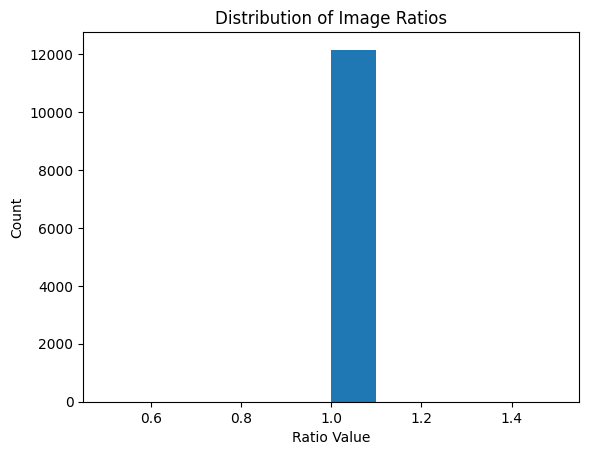

In [6]:
import matplotlib.pyplot as plt
RATIO_LIST = []
for set in (xtrain,xtest):
    for img in set:
        RATIO_LIST.append(img.shape[1]/img.shape[0])
        
plt.hist(RATIO_LIST)
plt.title('Distribution of Image Ratios')
plt.xlabel('Ratio Value')
plt.ylabel('Count')
plt.show()

In [7]:
ytrain_labels = np.argmax(ytrain, axis=1) 
ytest_labels = np.argmax(ytest, axis=1)

In [8]:
xtrain = np.array(xtrain) 
ytrain = np.array(ytrain)

In [9]:
train_counts = [] 
test_counts = [] 

for i in range(len(classes)): 
    train_counts.append(np.sum(ytrain_labels == i)) 
    test_counts.append(np.sum(ytest_labels == i))
import plotly.graph_objs as go 
Data = [] 
Data.append(go.Bar( x=classes, y=train_counts, name='Train Set' ))
Data.append(go.Bar( x=classes, y=test_counts, name='Test Set' ))
layout = go.Layout( title='Class distribution in Train/Test set', xaxis=dict(title='Class'), yaxis=dict(title='Number of images'), barmode='group' )
fig = go.Figure(data=Data, layout=layout) 
fig.show()

In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3),
activation='relu',
input_shape=(256,256,3)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3),
activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3),
activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

# Giảm overfitting
model.add(Dropout(0.5))

# 10 lớp bệnh
model.add(Dense(NoOfOutputLayer,
activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 128)      0

In [11]:
print(len(xtrain),len(ytrain))
print(len(xtest),len(ytest))

9716 9716
2429 2429


In [12]:
model1=model.fit(xtrain,ytrain,epochs=40,validation_data=(xtest,ytest) , batch_size=32,verbose=1,shuffle=False)

Epoch 1/40
304/304 [==============================] - 462s 2s/step - loss: 2.0089 - accuracy: 0.2699 - val_loss: 1.6951 - val_accuracy: 0.3841
Epoch 2/40
304/304 [==============================] - 411s 1s/step - loss: 1.6063 - accuracy: 0.4241 - val_loss: 1.2728 - val_accuracy: 0.5537
Epoch 3/40
304/304 [==============================] - 403s 1s/step - loss: 1.3250 - accuracy: 0.5226 - val_loss: 1.0875 - val_accuracy: 0.6208
Epoch 4/40
304/304 [==============================] - 449s 1s/step - loss: 1.0817 - accuracy: 0.6050 - val_loss: 0.9532 - val_accuracy: 0.6706
Epoch 5/40
304/304 [==============================] - 448s 1s/step - loss: 0.9055 - accuracy: 0.6574 - val_loss: 0.8231 - val_accuracy: 0.7011
Epoch 6/40
304/304 [==============================] - 475s 2s/step - loss: 0.7694 - accuracy: 0.7123 - val_loss: 0.8344 - val_accuracy: 0.7270
Epoch 7/40
304/304 [==============================] - 481s 2s/step - loss: 0.6447 - accuracy: 0.7459 - val_loss: 0.8057 - val_accuracy: 0.7250

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 128)      0

In [14]:
model.save('cnn_dwnld_model.h5')

In [15]:
ypred=model.predict(xtest)

76/76 [==============================] - 20s 255ms/step


In [16]:
ytest=np.argmax(ytest,axis=1)
ytest

array([5, 3, 5, ..., 5, 3, 3], dtype=int64)

In [17]:
ypred=np.argmax(ypred,axis=1)
ypred

array([5, 3, 5, ..., 5, 3, 3], dtype=int64)

In [18]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.84      0.60      0.70        96
           1       0.93      0.77      0.84        73
           2       0.82      0.57      0.67        74
           3       0.61      0.82      0.70       475
           4       0.86      0.65      0.74       268
           5       0.80      0.91      0.86       279
           6       0.91      0.64      0.75       131
           7       0.75      0.74      0.74       452
           8       0.89      0.87      0.88       357
           9       0.78      0.73      0.76       224

    accuracy                           0.77      2429
   macro avg       0.82      0.73      0.76      2429
weighted avg       0.79      0.77      0.77      2429



In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

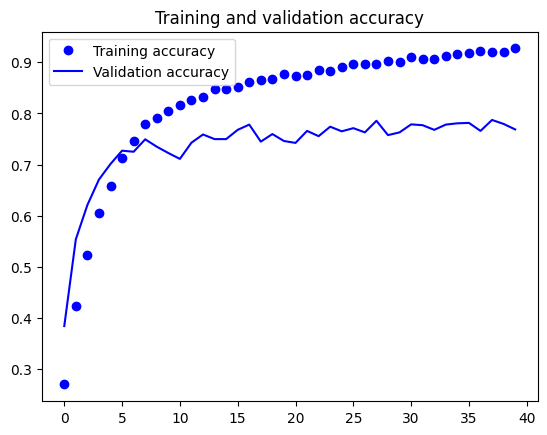

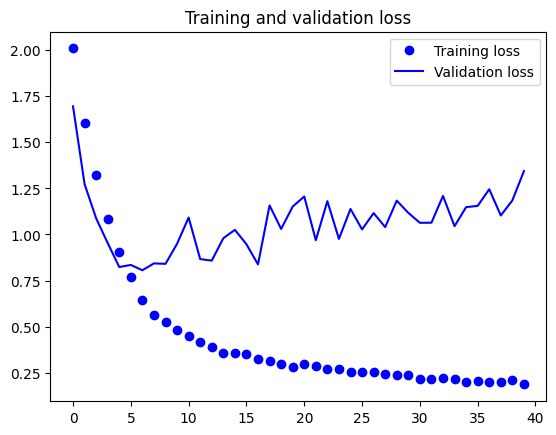

In [20]:
acc = model1.history['accuracy']
val_acc = model1.history['val_accuracy']
loss = model1.history['loss']
val_loss = model1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

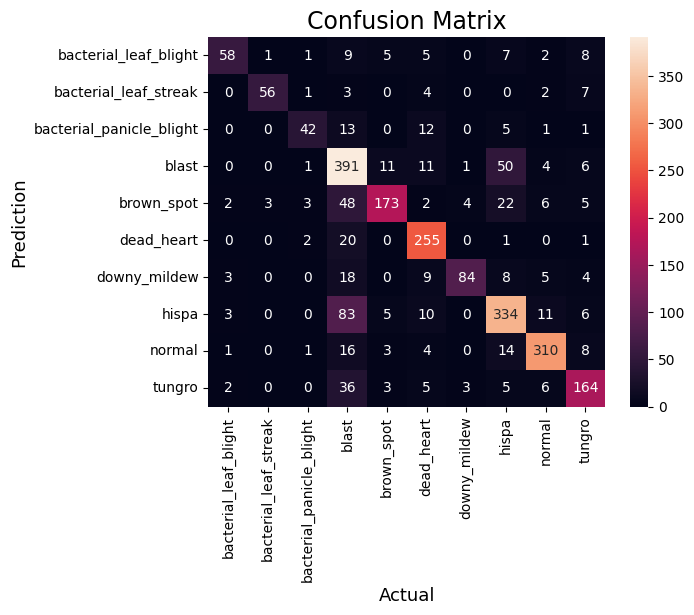

In [21]:
cm = confusion_matrix(ytest, ypred)
#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=["bacterial_leaf_blight", "bacterial_leaf_streak", "bacterial_panicle_blight", "blast", "brown_spot", "dead_heart", "downy_mildew", "hispa", "normal", "tungro"],
            yticklabels=["bacterial_leaf_blight", "bacterial_leaf_streak", "bacterial_panicle_blight", "blast", "brown_spot", "dead_heart", "downy_mildew", "hispa", "normal", "tungro"])
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

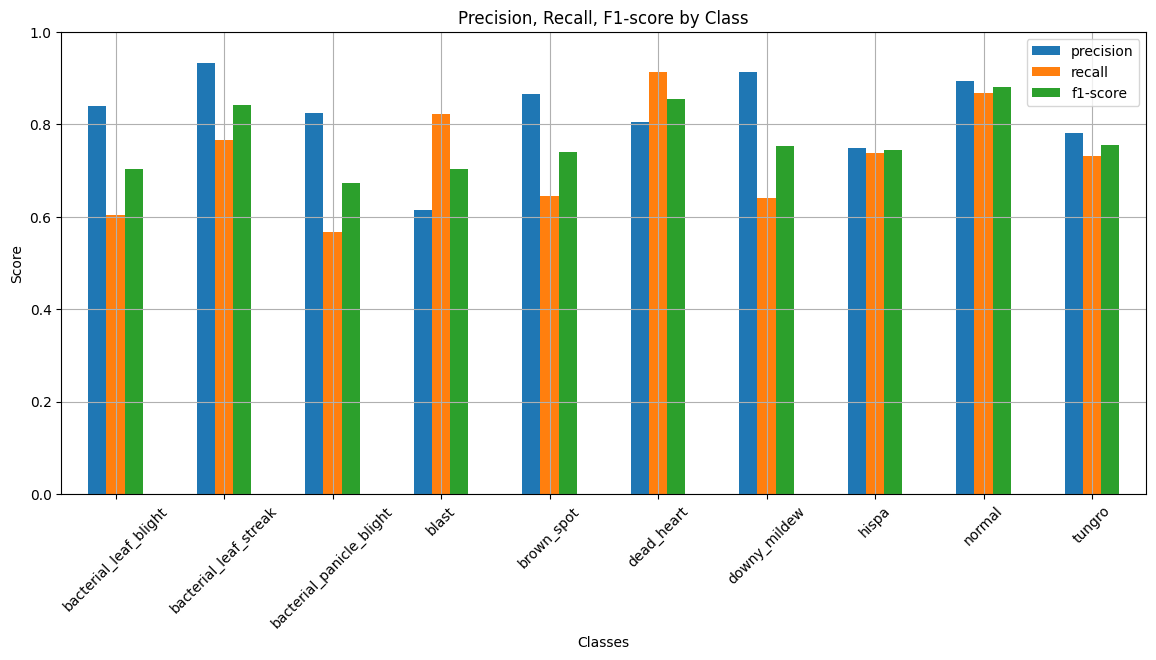

In [22]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Classification report
report = classification_report(
    ytest,
    ypred,
    target_names=classes,
    output_dict=True
)

# Chuyển sang DataFrame
df = pd.DataFrame(report).transpose()

# Chỉ lấy precision / recall / f1-score
metrics_df = df.iloc[:-3][['precision', 'recall', 'f1-score']]

# Vẽ biểu đồ
metrics_df.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("Precision, Recall, F1-score by Class")

plt.xlabel("Classes")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=45)

plt.grid(True)

plt.show()